# Univariate Regression Tutorial

In [29]:
import numpy as np

from MuyGPyS._test.sampler import UnivariateSampler, print_results
from MuyGPyS.gp import MuyGPS
from MuyGPyS.gp.deformation import Isotropy, l2
from MuyGPyS.gp.hyperparameter import AnalyticScale, Parameter
from MuyGPyS.gp.kernels import Matern
from MuyGPyS.gp.noise import HomoscedasticNoise
from MuyGPyS.neighbors import NN_Wrapper
from MuyGPyS.optimize import Bayes_optimize
from MuyGPyS.optimize.batch import sample_batch
from MuyGPyS.optimize.loss import lool_fn

In [2]:
np.random.seed(0)

## sampling a Curve from a Conventional GP

In [3]:
data_count = 3000
train_ratio = 0.075

In [4]:
nugget_noise = HomoscedasticNoise(1e-14)

In [5]:
measurement_noise = HomoscedasticNoise(1e-7)

In [6]:
sim_length_scale = Parameter(0.05)
sim_smoothness = Parameter(2.0)

In [7]:
sampler = UnivariateSampler(
    data_count=data_count,
    train_ratio=train_ratio,
    kernel=Matern(
        smoothness=sim_smoothness,
        deformation=Isotropy(
            l2,
            length_scale=sim_length_scale,
        ),
    ),
    noise=nugget_noise,
    measurement_noise=measurement_noise,
)

In [8]:
train_features, test_features = sampler.features()
print(train_features.shape)
print(test_features.shape)

(225,)
(2775,)


In [9]:
train_responses, test_responses = sampler.sample()

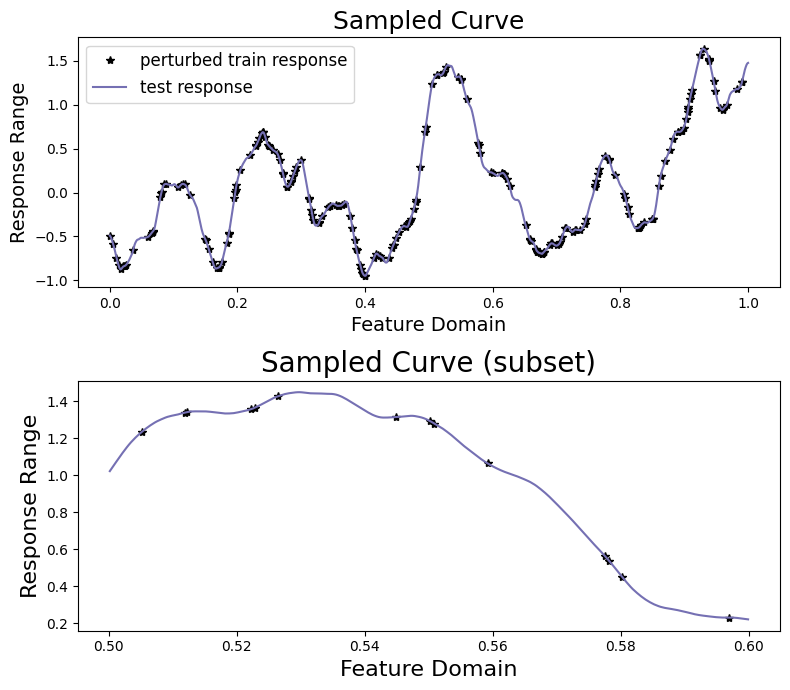

In [10]:
sampler.plot_sample()

## Constructing nearest Neighbor Lookups

In [11]:
nn_count = 30
nbrs_lookup = NN_Wrapper(train_features, nn_count, nn_method="exact", algorithm="ball_tree")

## Sampling Batches of Data

In [12]:
batch_count = sampler.train_count
#this sets the batch to be the size of the train_count, which is just all the data.
batch_indices, batch_nn_indices = sample_batch(
    nbrs_lookup, batch_count, sampler.train_count
)
#batch_count and train_count are the same. 255
#but in an actualy data set these would not be the same and batch would be smaller.
#the method needs the sizes of both the batch and all the data.

In [13]:
print(batch_indices.shape)
print(batch_nn_indices.shape)
#(255,) and (255, 30)
#one row for each training point used for indices.shape
# and then one column for each nearest neighbor for each training point, for nn_indices.shape
#these objects are np arrays.

(225,)
(225, 30)


In [14]:
print(batch_indices[0:5])
print(batch_nn_indices[0:5])
print(train_features[0:5])

[0 1 2 3 4]
[[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
  25 26 27 28 29 30]
 [ 0  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
  25 26 27 28 29 30]
 [ 3  1  4  0  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
  25 26 27 28 29 30]
 [ 2  4  5  1  6  7  8  0  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
  25 26 27 28 29 30]
 [ 3  5  6  7  2  8  1  0  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
  25 26 27 28 29 30]]
[0.00033344 0.00533511 0.01033678 0.01367122 0.01733911]


## Setting and Optimizing Hyperparameters

In [15]:
muygps = MuyGPS(
    kernel=Matern(
        smoothness=Parameter("log_sample", (0.1, 5.0)),
        deformation=Isotropy(
            l2,
            length_scale=sim_length_scale,
        ),
    ),
    noise=measurement_noise,
    scale=AnalyticScale(),
)

In [16]:
#AI generated, not confirmed notes. check documentation.
batch_crosswise_dists = muygps.kernel.deformation.crosswise_tensor(
    train_features, #← where to look up the batch points' coordinates
    train_features, #← where to look up the neighbors' coordinates
    batch_indices, # ← which rows in the first argument are the batch points
    batch_nn_indices, # ← which rows in the second argument are the neighbors
)

In [17]:
pairwise_dists = muygps.kernel.deformation.pairwise_tensor(
    train_features, batch_nn_indices
)

In [18]:
batch_targets = train_responses[batch_indices]
batch_nn_targets = train_responses[batch_nn_indices]

In [19]:
#This does the above steps, but all with one function for conevencies sake. It returns the same values.
(
    batch_crosswise_dists,
    batch_pairwise_dists,
    batch_targets,
    batch_nn_targets,
) = muygps.make_train_tensors(
    batch_indices,
    batch_nn_indices,
    train_features,
    train_responses,
)

In [20]:
Kcross = muygps.kernel(batch_crosswise_dists)
Kin = muygps.kernel(pairwise_dists)

#these are the kernel tensors.

#there are the distance tensors above which store the tensors from each batch point to it's neighbors
#as well as, for each batch point, between each of the neighbors and each other.

#and there are the kernel tensors, which store the covariance of how these distances translate into correlation.

#you wnat both the batch point's relations, and the relations between it's nieghbors,
#so that you can find out which neighbors should "share" their contriobution between them because they're similar.
#you need the pairwise kernel, in addition to the distances, in order to find out which
#points to attribute with being used for hte answer.

#This is actually unncessary, and is only here for explaning the inner workings of GPs. Bayes_optimize recreates
#these each optimization run with different hyperparameters to find the best kernels and what hyperparameters get it.

Tensor are a data shape, covariance is weights. Tensors store actual scalar values of distances between points, The covariance is the weights of how points relate based on those distances. Kernels are tensors that store covariance. hyperparameters are variables that effect how the covariances are calcualted from the distances.

we calculate the distance tensors between a point and it's neighbors (crowsswise: used to know how much neighbor points influence a point), as well as the distances between each of the neighbors and each other (pairwise: used to know if two neighbors need their influence "combined", since they're close together and so likely contribute the same thing and we don't need that doubled, so take that into account when finding out how much a single neighbor influences a point). Then using these distance tensors we calculate kernel tensors which store the actual covariance/weights. a datapoints contribution to a guess is based on how far away it is, and how alone it is. farther away points contribute less then close points, and a point in a group would contribute less then a point alone.

You then use an optimization algorithm to adjust the hyperparameters which dictate how these covariance kernels are calculated, to find the hyperparameters that give you the covriance kernels which give you the best guesses, determined by how close the guesses were to the training data target values. so it calculates guesses for the training data locations, and then compares the gusses with the actual values to see how off it was, then change the hyperparameters slightly do it all again and see if it did better.

The hyperparameters are used to turn the distances of points, stored in tensors, and turn them into weights, stored in kernels.

you can then calculate new crosswise distance tensors between the points you want to know and the neighbors (which you used as training data) with actual values. you also calculate the pairwise distance tensors again to know how a nodes close neighbors contribute together, just like with the training data. (Because the pairwise distances between the training points here is the same as the pairwise distances between the training points used to optimize the algorithm. so the weights between two points will be the same as the weights calculated when you found the best hyperparameters. the only difference is they're grouped differently, because they're grouped based on what test node they're close to, instead of train nodes.) you then calculate new crosswise and pairwise tensor kernels, using the optimized hyperparameters, for the points you want to know. these kernels focused on the points your asking about, only calculating the covariances that are close and important because you only used the closest N neighbors. you have to recalculate these the kernels when you make guesses, you wouldn't calculate guesses for every possible point before you even need them, it would be expensive, a lot of calculations go into making a guess. you don't use the old kernels because those weights made guesses for the training data, in relation to the training points which you don't need. You need them in relation to the guessing points.

you then use the .posterior_means() function, passing in the kernels and the values of the neighbors of each point, to collapse the kernels into actual guesses for each point. With the pairwise kernel tracking neighbor weights/contributions based on how close together they are (so that a bunch of nearby neighbors would contribute just as much a single neighbor on its own. or maybe MuyGPs has a way of attributing more certainity to a bunch of points together since that'd be more likely to be true, so they get slightly more weight. But point is they don't each get full weights if in a group.), and the crosswise kernel tracking contributions/weights based on how far they are from the point your guessing, and then the nighbor values get passed in to make the actual guesses based on the values the neighbors actually have.

while posterior means are the guesses, posterior variance is how certain those guesses are. By using how far away the points were, it knows if the guess for a point can be sure or not. if all nearest neighbors are far, it can't be sure. But that's crosswise distances, do pairwise distances effect the variance? 

Because the contributions are stored in kernels, but the actual values are completely seperate, if you had completely differnt vales for the same points, you could reuse the kernels and it be fully accurate. So in the context of guessing AQIs, with the datapoints being sites, you could reuse the crosswise and pairwise kernels you calculated, give it the site data from a different time, and it can make guesses of AQIs at the same places based on that time.

In [21]:
muygps_optimized = Bayes_optimize(
    muygps,
    batch_targets,
    batch_nn_targets,
    batch_crosswise_dists,
    batch_pairwise_dists,
    loss_fn=lool_fn,
    verbose=True,
    random_state=1,
    init_points=5,
    n_iter=15,
)

parameters to be optimized: ['smoothness']
bounds: [[0.1 5. ]]
initial x0: [0.92898658]
|   iter    |  target   | smooth... |
-------------------------------------
| 1         | 1826.4155 | 0.9289865 |
| 2         | 2359.1138 | 2.1434078 |
| 3         | 1952.9148 | 3.6295900 |
| 4         | 614.37693 | 0.1005604 |
| 5         | 2308.5373 | 1.5814296 |
| 6         | 1707.0280 | 0.8191038 |
| 7         | 1480.0459 | 5.0       |
| 8         | 2201.7376 | 2.8304404 |
| 9         | 2373.3713 | 1.8833218 |
| 10        | 2373.2705 | 1.9964934 |
| 11        | 2374.7107 | 1.9380977 |
| 12        | 2374.7107 | 1.9380449 |
| 13        | 2374.7107 | 1.9379599 |
| 14        | 2374.7107 | 1.9378822 |
| 15        | 2374.7107 | 1.9378118 |
| 16        | 2374.7107 | 1.9377529 |
| 17        | 2374.7107 | 1.9376099 |
| 18        | 2374.6874 | 1.9451051 |
| 19        | 2374.6566 | 1.9266613 |
| 20        | 2374.6478 | 1.9498348 |
| 21        | 2374.6508 | 1.9260852 |


In [22]:
muygps_optimized = muygps_optimized.optimize_scale(batch_pairwise_dists, batch_nn_targets)

## Inference

In [23]:
test_count = test_features.shape[0]
#get the indices of all the test points
indices = np.arange(test_count)
#get the indices of the neighbors for each of those test points as well
test_nn_indices, _ = nbrs_lookup.get_nns(test_features)

In [24]:
#create tesors to store the crosswise distances and pairwise distances between points and the point's neighbors.
#as well as the actual values for each points neighbors.
(
    test_crosswise_dists,
    test_pairwise_dists,
    test_nn_targets,
) = muygps.make_predict_tensors(
    indices,
    test_nn_indices,
    test_features,
    train_features,
    train_responses,
)
#test_nn_targets are the values for the neighbors of each point your asking about. these neighbors are the same points that were your training data, you know them.

In [25]:
#calculate kernels to store the crosswise covariance and pairwise covariance. these are used to know how much a points neighbors in
Kcross = muygps_optimized.kernel(test_crosswise_dists)
Kin = muygps_optimized.kernel(test_pairwise_dists)

In [26]:
#Take the crosswise covariance and pairwise covariance to know how the neighbors effect each point,
#and then use the values of the points to calculate the actual value based on the neighbors influence.
predictions = muygps_optimized.posterior_mean(Kin, Kcross, test_nn_targets)
#because mean was removed from the datapoints before, need to add it back in.
variances = muygps_optimized.posterior_variance(Kin, Kcross)
#get the range that values need to be in in order to fall within 95% certainty.
confidence_intervals = np.sqrt(variances) * 1.96
#coverage is the proportion of guesses that differ from the true response by no more than the confidence interval size.
coverage = np.count_nonzero(np.abs(test_responses - predictions) < confidence_intervals) / test_count

In [27]:
#print the results of the model
print_results(
    test_responses, ("optimized", muygps_optimized, predictions, variances, confidence_intervals, coverage)
)

#variance scale represents how much the data changes across the entire dataset. its' squared though, needs to be squar rooted to get the actual value.
#mean variance, also needing to be square rooted because it's squared, represents on average how wide the true value migt be from it's guess.

name,smoothness,length scale,noise variance,variance scale,rmse,mean variance,mean confidence interval,coverage
optimized,1.937753,0.050000,0.000000,0.752759,0.016121,0.000239,0.018134,0.956036


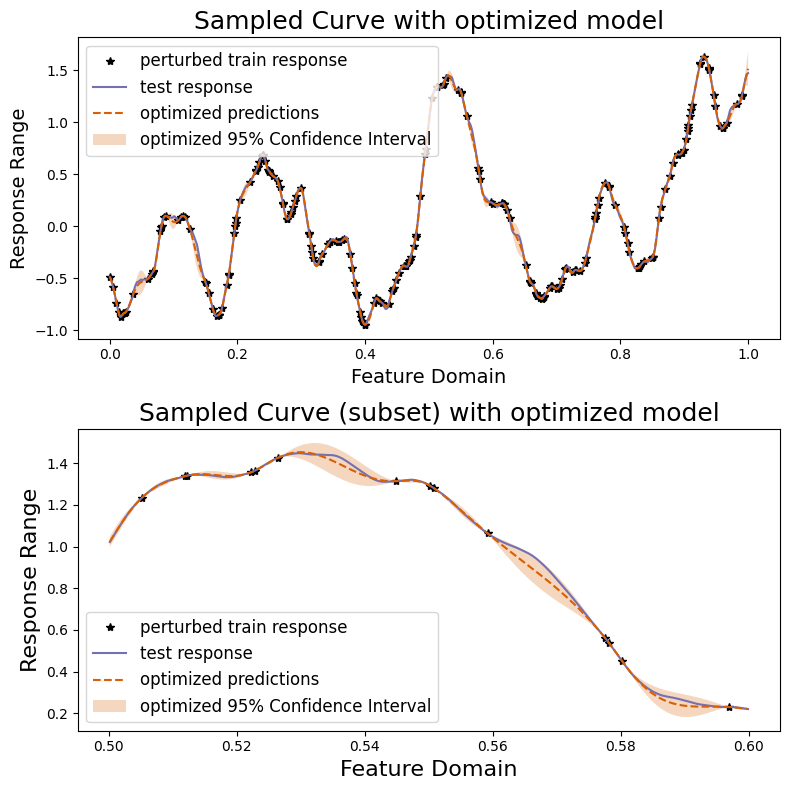

In [28]:
sampler.plot_results(("optimized", predictions, confidence_intervals))